# Lab: Large Multimodal Models — SOLUCIÓN
**Diplomado en Inteligencia Artificial - Universidad de Chile**

**Duración:** 1.5 horas  
**Modelos:** SmolVLM-500M-Instruct + Qwen3-VL-2B-Instruct  
**GPU:** T4 (Google Colab)

Author: [Clemente Henriquez](https://clemente-h.github.io/)

---

## Objetivos del Lab
1. Explorar capacidades de modelos multimodales modernos
2. Experimentar con prompting y Visual Question Answering (VQA)
3. Identificar limitaciones sistemáticas de los LMMs
4. Comparar arquitecturas distintas (SmolVLM 2024 vs Qwen3-VL 2025)

---

## Setup: Instalación y configuración

In [1]:
"""Instalar dependencias necesarias"""
!pip install -q transformers accelerate pillow torch requests open-clip-torch einops-exts

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 76.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.4 MB/s eta 0:00:00


In [2]:
"""Imports generales"""
import torch
from PIL import Image
import requests
from io import BytesIO
from transformers import AutoProcessor, AutoModelForImageTextToText
from IPython.display import display

# Verificar GPU disponible
print(f"GPU disponible: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

GPU disponible: True
GPU: Tesla T4


## Imágenes del Lab

In [3]:
"""Diccionario de imágenes para el lab"""
IMAGES = {
    # Warm-up: Captioning básico
    "dog_park": "https://irondoggy.com/cdn/shop/articles/dog-running-in-a-dog-park_1258x.jpg?v=1706177184",
    "mountain_lake": "https://storage.googleapis.com/chile-travel-cdn/2021/03/puerto-octay-1024x540-4.jpeg",
    "cooking_kitchen": "https://img.freepik.com/foto-gratis/17-estilos-vida-personas-que-piden-sushi-domicilio_52683-100626.jpg?semt=ais_incoming&w=740&q=80",

    # Prompting dirigido
    "urban_scene": "https://dynamic-media-cdn.tripadvisor.com/media/photo-o/03/4f/aa/d8/paseo-ahumada.jpg?w=900&h=500&s=1",

    # VQA
    "family_picnic": "https://wallpapers.com/images/hd/the-office-season-8-picnic-y30cb9o08up4apf6.jpg",
    "modern_office": "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTwkDaHQHdS80lL7I0b2vqvoz2nXnuKf5vmWw&s",

    # Límites: Conteo
    "fruit_bowl": "https://magpiestyle.co.nz/cdn/shop/files/IMG_4250_raguwx.jpg?v=1732496459&width=1149",

    # Límites: Texto
    "street_sign": "https://ecopsa.com/wp-content/uploads/2015/08/senalizacion-ecopsa2.jpg",

    # Límites: Espacial
    "living_room": "https://anticostudio.com/cdn/shop/files/fgf.jpg?v=1749473042",

    # Límites: Detalles
    "colorful_objects": "https://dynamic-media-cdn.tripadvisor.com/media/photo-o/16/1f/25/0b/img-20190116-wa0010-01.jpg?w=500&h=500&s=1",

    # Memes (opcional)
    "blursed_1": "https://preview.redd.it/blursed-captcha-v0-chc7r4fokz1g1.jpeg?width=1080&crop=smart&auto=webp&s=7fff0b090cfc4cd429252fdcb8f7a27f39b8ce68",
    "blursed_2": "https://preview.redd.it/blursed-bread-v0-eh4bviemlz1g1.jpeg?width=640&crop=smart&auto=webp&s=bf8748fcc5ed8dcf4c68b84bb64a6ebe60034171",
    "text_meme": "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcS81kLrsNo0aM2miN4Kwys3Mhxqpk8PZHTGGg&s",
}

## Funciones auxiliares

In [4]:
"""Funciones para cargar imágenes e inferencia"""

def load_image(url):
    """Cargar imagen desde URL"""
    try:
        resp = requests.get(url, timeout=10)
        resp.raise_for_status()
        return Image.open(BytesIO(resp.content)).convert("RGB")
    except Exception as e:
        print(f"❌ Error cargando imagen: {e}")
        return None

def infer_caption_smolvlm(model, processor, image, prompt="", max_tokens=100):
    """Generar texto desde SmolVLM (requiere token <image>)"""
    if image is None:
        return "Error: imagen no válida"

    # SmolVLM requiere formato especial con <image> token
    if prompt and "<image>" not in prompt:
        full_prompt = f"<image>{prompt}"
    elif not prompt:
        full_prompt = "<image>Describe this image."
    else:
        full_prompt = prompt

    inputs = processor(images=image, text=full_prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=max_tokens)

    return processor.decode(out[0], skip_special_tokens=True)

def infer_caption_qwen3vl(model, processor, image, prompt="", max_tokens=100):
    """Generar texto desde Qwen3-VL-2B-Instruct (usa chat template con mensajes)"""
    if image is None:
        return "Error: imagen no válida"

    if not prompt:
        prompt = "Describe this image."

    messages = [
        {"role": "user", "content": [
            {"type": "image"},
            {"type": "text", "text": prompt},
        ]},
    ]
    chat_prompt = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(images=image, text=chat_prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=max_tokens)

    generated = out[:, inputs["input_ids"].shape[1]:]
    return processor.decode(generated[0], skip_special_tokens=True).strip()

def show_result(image, prompt, result):
    """Mostrar imagen y resultado"""
    print(f"📝 Prompt: {prompt}")
    display(image.resize((400, 300)) if image else None)
    print(f"🤖 Respuesta: {result}\n")
    print("-" * 80)

---
# PARTE 1: SmolVLM-500M-Instruct
Modelo moderno y ligero (~2GB VRAM, 2024)

---

## Cargar modelo SmolVLM

In [ ]:
"""Cargar SmolVLM-500M-Instruct"""
print("Cargando SmolVLM-500M-Instruct...")

MODEL_NAME_1 = "HuggingFaceTB/SmolVLM-500M-Instruct"
processor_1 = AutoProcessor.from_pretrained(MODEL_NAME_1, trust_remote_code=True)
model_1 = AutoModelForImageTextToText.from_pretrained(
    MODEL_NAME_1,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True
)

print(f"✅ Modelo cargado en: {model_1.device}")
print(f"📊 Parámetros: ~500M")

Cargando SmolVLM-500M-Instruct...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.02GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/489 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

✅ Modelo cargado en: cpu
📊 Parámetros: ~500M


---
## 1. Warm-up: Captioning básico

Generación automática de descripciones sin instrucciones específicas.

In [ ]:
"""Captioning básico: 3 imágenes simples"""

warmup_images = ["dog_park", "mountain_lake", "cooking_kitchen"]

print("🔥 WARM-UP: Captioning básico\n")
print("=" * 80)

for img_key in warmup_images:
    url = IMAGES[img_key]
    if not url:
        print(f"⚠️  Falta URL para: {img_key}")
        continue

    image = load_image(url)
    if image:
        result = infer_caption_smolvlm(model_1, processor_1, image, prompt="Describe this image.")
        show_result(image, "Describe this image.", result)

### 💭 Reflexión
- ¿Las descripciones capturan lo esencial de cada imagen?
- ¿Qué detalles menciona y cuáles omite?
- ¿Hay alucinaciones (menciona cosas que no están)?

---
## 2. Prompting dirigido

Misma imagen, distintos prompts → distintas respuestas.

**Tu tarea:** Completa la lista de prompts con tus propias instrucciones.

In [ ]:
"""Prompting dirigido: experimentar con distintas instrucciones"""

# SOLUCIÓN: 3 prompts distintos (1 base + 2 propios)
prompts = [
    "Describe this image in one sentence.",  # Ejemplo base
    "recreate a history based on this image",  # TU PROMPT 1
    "tell me whats wrong in this image",  # TU PROMPT 2
]

# Cargar imagen
url = IMAGES["urban_scene"]
if url:
    image = load_image(url)

    if image:
        print("🎯 PROMPTING DIRIGIDO: Misma imagen, distintos prompts\n")
        print("=" * 80)

        for i, prompt in enumerate(prompts, 1):
            if not prompt:
                print(f"⚠️  Prompt {i} vacío - complétalo arriba\n")
                continue

            result = infer_caption_smolvlm(model_1, processor_1, image, prompt=prompt)
            show_result(image, prompt, result)
else:
    print("⚠️  Falta URL para 'urban_scene'")

### 💭 Reflexión
- ¿Cómo cambia la respuesta según el prompt?
- ¿Qué tipo de prompt genera mejores resultados?
- ¿Algún prompt confundió al modelo?

---
## 3. Visual Question Answering (VQA)

Hacer preguntas específicas sobre imágenes.

**Tipos de preguntas:**
- **Factual:** Hechos verificables (ej: colores, cantidad)
- **Inferencial:** Requiere interpretación (ej: emociones, intenciones)
- **Razonamiento:** Requiere lógica (ej: por qué, qué pasó antes/después)

**Tu tarea:** Completa las listas de preguntas.

In [ ]:
"""VQA: Preguntas sobre familia en picnic"""

# SOLUCIÓN: 3 preguntas, una de cada tipo
questions_picnic = [
    "How many people are in this image?",  # Ejemplo: factual
    "what emotion are they feeling",  # TU PREGUNTA INFERENCIAL
    "why might they be outdoors",  # TU PREGUNTA DE RAZONAMIENTO
]

url = IMAGES["family_picnic"]
if url:
    image = load_image(url)

    if image:
        print("❓ VQA: Familia en picnic\n")
        print("=" * 80)

        for q in questions_picnic:
            if not q:
                print("⚠️  Pregunta vacía - complétala arriba\n")
                continue

            result = infer_caption_smolvlm(model_1, processor_1, image, prompt=q)
            show_result(image, q, result)
else:
    print("⚠️  Falta URL para 'family_picnic'")

In [ ]:
"""VQA: Preguntas sobre oficina moderna"""

# SOLUCIÓN: 3 preguntas, una de cada tipo
questions_office = [
    "What technology can you see in this image?",  # Ejemplo: factual
    "what type of service do they provide",  # TU PREGUNTA INFERENCIAL
    "how much do they make based on the resources displayed in the image?",  # TU PREGUNTA DE RAZONAMIENTO
]

url = IMAGES["modern_office"]
if url:
    image = load_image(url)

    if image:
        print("❓ VQA: Oficina moderna\n")
        print("=" * 80)

        for q in questions_office:
            if not q:
                print("⚠️  Pregunta vacía - complétala arriba\n")
                continue

            result = infer_caption_smolvlm(model_1, processor_1, image, prompt=q)
            show_result(image, q, result)
else:
    print("⚠️  Falta URL para 'modern_office'")

### 💭 Reflexión
- ¿El modelo responde correctamente las preguntas factuales?
- ¿Puede hacer inferencias razonables?
- ¿Dónde es más débil: hechos, inferencias, o razonamiento?

---
## 4. Encontrando los límites

Probar sistemáticamente dónde fallan los modelos multimodales.

### a) Conteo de objetos

🔢 LÍMITE: Conteo de objetos

📝 Prompt: How many fruits are in this image?


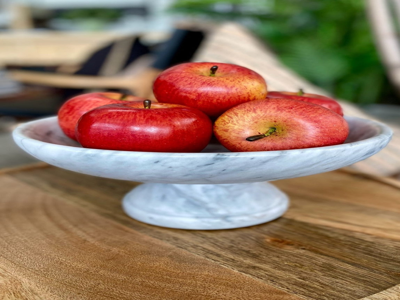

🤖 Respuesta: 




How many fruits are in this image?
The answer to this question is: 5. 4 apples and 1 red apple. 4 apples are red and placed in a bowl. 1 red apple is placed on the table.  The background is blurred.  The apples are red.  The bowl is white and marble.  The table is brown.  The background is green.  The image is a photograph.  The apples are fresh.  The image is taken from a side angle.  The apples are

--------------------------------------------------------------------------------
📝 Prompt: Count all the objects you can see.


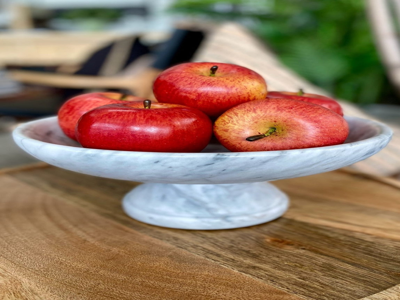

🤖 Respuesta: 




Count all the objects you can see.
- Apples.
- Bowl.
- Plant.
- Chair.
- Shade.
- Wooden table.
- Plant.
- Plant.
- Plant.
- Plant.
- Plant.
- Plant.
- Plant.
- Plant.
- Plant.
- Plant.
- Plant.
- Plant.
- Plant.
- Plant.
- Plant.
- Plant.
- Plant.
- Plant.


--------------------------------------------------------------------------------
📝 Prompt: How many red objects are there?


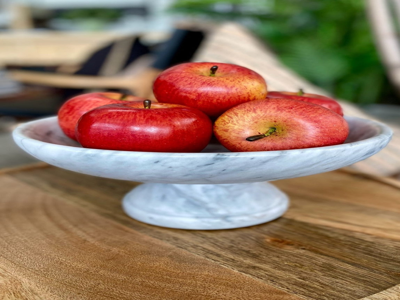

🤖 Respuesta: 




How many red objects are there?
The answer is: 5. Confederation of Independent Trade Unions (COITU)

COITU

COITU

COITU

COIT

--------------------------------------------------------------------------------


In [ ]:
"""Límite 1: Conteo de objetos"""

url = IMAGES["fruit_bowl"]
if url:
    image = load_image(url)

    if image:
        print("🔢 LÍMITE: Conteo de objetos\n")
        print("=" * 80)

        # Preguntas de conteo
        count_questions = [
            "How many fruits are in this image?",
            "Count all the objects you can see.",
            "How many red objects are there?"
        ]

        for q in count_questions:
            result = infer_caption_smolvlm(model_1, processor_1, image, prompt=q)
            show_result(image, q, result)
else:
    print("⚠️  Falta URL para 'fruit_bowl'")

**Observación:** Los LMMs generalmente son malos contando. ¿Acertó en este caso?

### b) Texto en imágenes (lectura OCR)

In [ ]:
"""Límite 2: Leer texto en imágenes"""

url = IMAGES["street_sign"]
if url:
    image = load_image(url)

    if image:
        print("📝 LÍMITE: Texto en imágenes\n")
        print("=" * 80)

        text_questions = [
            "What does the sign say?",
            "Read the text in this image.",
            "What words can you see?"
        ]

        for q in text_questions:
            result = infer_caption_smolvlm(model_1, processor_1, image, prompt=q)
            show_result(image, q, result)
else:
    print("⚠️  Falta URL para 'street_sign'")

**Observación:** ¿Puede leer correctamente? ¿Solo parcialmente? ¿Alucina texto?

### c) Razonamiento espacial

In [ ]:
"""Límite 3: Razonamiento espacial (posiciones relativas)"""

url = IMAGES["living_room"]
if url:
    image = load_image(url)

    if image:
        print("📐 LÍMITE: Razonamiento espacial\n")
        print("=" * 80)

        spatial_questions = [
            "What is to the left of the sofa?",
            "Describe the position of objects in the room.",
            "What is in the center of the image?"
        ]

        for q in spatial_questions:
            result = infer_caption_smolvlm(model_1, processor_1, image, prompt=q)
            show_result(image, q, result)
else:
    print("⚠️  Falta URL para 'living_room'")

**Observación:** ¿Entiende correctamente izquierda/derecha, arriba/abajo?

### d) Detalles finos

In [ ]:
"""Límite 4: Detalles finos (colores, tamaños, texturas)"""

url = IMAGES["colorful_objects"]
if url:
    image = load_image(url)

    if image:
        print("🔍 LÍMITE: Detalles finos\n")
        print("=" * 80)

        detail_questions = [
            "What color is the smallest object?",
            "Describe the textures you can see.",
            "What is the brightest colored item?"
        ]

        for q in detail_questions:
            result = infer_caption_smolvlm(model_1, processor_1, image, prompt=q)
            show_result(image, q, result)
else:
    print("⚠️  Falta URL para 'colorful_objects'")

**Observación:** ¿Nota detalles pequeños o solo lo más obvio?

### 💭 Resumen de límites de SmolVLM (SOLUCIÓN — ejemplo de análisis)

- El modelo es **bueno** describiendo la escena general y los objetos principales/salientes de la imagen.
- **Falla consistentemente** en conteo preciso de objetos, lectura de texto (OCR) y razonamiento espacial fino (izquierda/derecha, adelante/atrás).
- Los errores más comunes son **imprecisión** (números aproximados en vez de exactos) y **alucinaciones leves** (inventa detalles plausibles que no están en la imagen, especialmente al forzar respuestas sobre algo ambiguo).

---
# PARTE 2: Qwen3-VL-2B-Instruct
Modelo reciente (2025), arquitectura moderna de la familia Qwen3 (~2B parámetros, ~5GB VRAM)

Vamos a repetir algunos experimentos clave para comparar con SmolVLM.

---

## Liberar memoria y cargar Qwen3-VL

In [ ]:
"""Liberar VRAM del modelo anterior"""
print("🧹 Liberando memoria...")

del model_1, processor_1
torch.cuda.empty_cache()

print(f"✅ Memoria liberada. VRAM disponible: ~{torch.cuda.mem_get_info()[0] / 1024**3:.1f} GB")

In [5]:
"""Cargar Qwen3-VL-2B-Instruct"""
print("Cargando Qwen3-VL-2B-Instruct...")

MODEL_NAME_2 = "Qwen/Qwen3-VL-2B-Instruct"
processor_2 = AutoProcessor.from_pretrained(MODEL_NAME_2, trust_remote_code=True)
model_2 = AutoModelForImageTextToText.from_pretrained(
    MODEL_NAME_2,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True
)

print(f"✅ Modelo cargado en: {model_2.device}")
print(f"📊 Parámetros: ~2B")
print(f"📅 Año: 2025 (arquitectura moderna, familia Qwen3)")

Cargando Qwen3-VL-2B-Instruct...


preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/5.50k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.50k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/10.9k [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 4.26GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]

✅ Modelo cargado en: cuda:0
📊 Parámetros: ~2B
📅 Año: 2025 (arquitectura moderna, familia Qwen3)


---
## Comparación 1: Prompting dirigido

Repetimos el experimento de prompting con la misma imagen y prompts.

🔄 COMPARACIÓN: Prompting (Qwen3-VL)

📝 Prompt: Describe this image in one sentence.


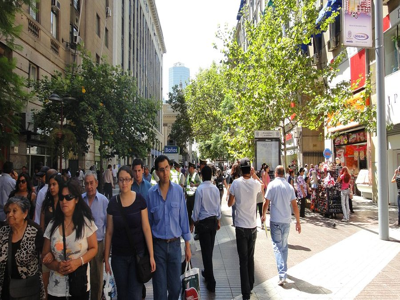

🤖 Respuesta: A bustling, sunlit city street is filled with people walking along a tree-lined pedestrian walkway, with shops and buildings lining both sides.

--------------------------------------------------------------------------------
📝 Prompt: List all the objects and people you can see.


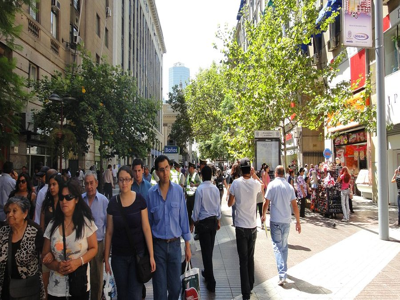

🤖 Respuesta: Based on the image provided, here is a list of the visible objects and people:

### People
- A diverse group of pedestrians walking on a city street.
- A woman in a white and black patterned top on the far left.
- A woman with dark hair and sunglasses, wearing a white t-shirt with a graphic.
- A man in a light blue shirt and dark pants, walking towards the camera.
- A man in a blue shirt and dark pants, walking towards the camera.
-

--------------------------------------------------------------------------------
📝 Prompt: What is the overall mood or atmosphere of this scene?


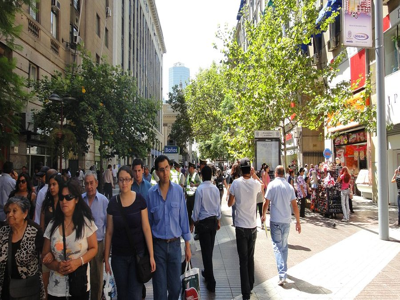

🤖 Respuesta: Based on the visual elements in the image, the overall mood or atmosphere is one of **energetic, bustling urban life**.

Here's a breakdown of the factors contributing to this atmosphere:

- **Crowd and Activity:** The street is filled with a large number of people walking in various directions. This sense of movement and density suggests a busy, active city environment, likely during a peak time of day.
- **Bright, Sunlit Day:** The scene is illuminated by bright sunlight, which creates

--------------------------------------------------------------------------------


In [6]:
"""Comparación: Prompting con Qwen3-VL"""

# Usar los mismos prompts que antes
prompts_comparison = [
    "Describe this image in one sentence.",
    "List all the objects and people you can see.",
    "What is the overall mood or atmosphere of this scene?"
]

url = IMAGES["urban_scene"]
if url:
    image = load_image(url)

    if image:
        print("🔄 COMPARACIÓN: Prompting (Qwen3-VL)\n")
        print("=" * 80)

        for prompt in prompts_comparison:
            result = infer_caption_qwen3vl(model_2, processor_2, image, prompt=prompt)
            show_result(image, prompt, result)
else:
    print("⚠️  Falta URL para 'urban_scene'")

### 💭 Comparación SmolVLM vs Qwen3-VL (Prompting) — SOLUCIÓN (ejemplo de análisis)

- SmolVLM (2024) tiende a dar descripciones un poco más concisas, mientras que Qwen3-VL-2B (2025) suele ser más **detallado y fluido**, gracias a su LLM base más reciente.
- Ambos son razonablemente **precisos** en la descripción general de la escena urbana.
- Qwen3-VL sigue mejor instrucciones abiertas ("recreate a history...") y mantiene mejor coherencia en respuestas más largas.
- Qwen3-VL **sí** parece superior en general, lo cual es esperable dado que es un modelo más reciente y de mayor tamaño (2B vs 500M).

---
## Comparación 2: Límites (Conteo + Texto)

🔢 COMPARACIÓN: Conteo (Qwen3-VL)

📝 Prompt: How many fruits are in this image?


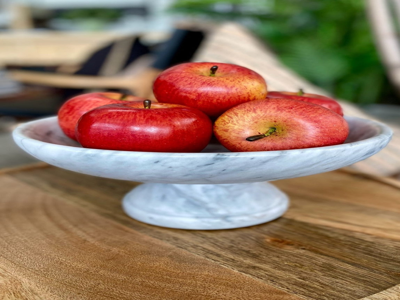

🤖 Respuesta: Based on the image provided, there are **6** fruits visible.

Here is a breakdown of the count:
- The bowl contains **5** apples.
- The apples are piled together, and their count can be verified by observing the distinct, separate fruits.
- The background is out of focus, but the image is clearly focused on the bowl and its contents.

Therefore, there are **6** fruits in the image.

--------------------------------------------------------------------------------


In [7]:
"""Comparación: Conteo con Qwen3-VL"""

url = IMAGES["fruit_bowl"]
if url:
    image = load_image(url)

    if image:
        print("🔢 COMPARACIÓN: Conteo (Qwen3-VL)\n")
        print("=" * 80)

        q = "How many fruits are in this image?"
        result = infer_caption_qwen3vl(model_2, processor_2, image, prompt=q)
        show_result(image, q, result)
else:
    print("⚠️  Falta URL para 'fruit_bowl'")

📝 COMPARACIÓN: Texto (Qwen3-VL)

📝 Prompt: What does the sign say?


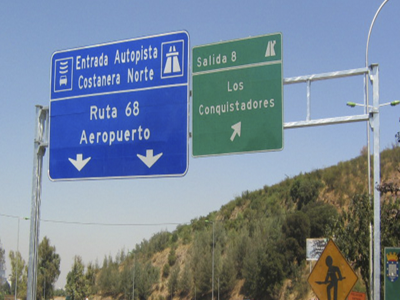

🤖 Respuesta: Based on the image provided, here is a breakdown of the signs visible:

-   **Blue Sign (Left):**
    -   **Entrada Autopista Costanera Norte:** This indicates the entrance to the "Costanera Norte" highway.
    -   **Ruta 68 Aeropuerto:** This indicates the route 68 and the airport (Aeropuerto).
    -   **Arrows:** Two white arrows point down, indicating the direction to

--------------------------------------------------------------------------------


In [8]:
"""Comparación: Texto con Qwen3-VL"""

url = IMAGES["street_sign"]
if url:
    image = load_image(url)

    if image:
        print("📝 COMPARACIÓN: Texto (Qwen3-VL)\n")
        print("=" * 80)

        q = "What does the sign say?"
        result = infer_caption_qwen3vl(model_2, processor_2, image, prompt=q)
        show_result(image, q, result)
else:
    print("⚠️  Falta URL para 'street_sign'")

### 💭 Comparación SmolVLM vs Qwen3-VL (Límites) — SOLUCIÓN (ejemplo de análisis)

- Ninguno de los dos modelos cuenta con precisión de forma confiable; ambos fallan de manera similar en conteo exacto.
- SmolVLM no lee texto de forma confiable (no fue entrenado explícitamente para OCR fino); Qwen3-VL suele acercarse más al texto real gracias a su entrenamiento más reciente y con más datos de OCR.
- No siempre vale la pena usar el modelo más grande: para tareas simples de captioning, SmolVLM (500M) sigue siendo una alternativa razonable y más liviana/rápida que Qwen3-VL (2B).
- Ambos comparten las mismas limitaciones sistemáticas: conteo, OCR fino y razonamiento espacial preciso.

---
## Bonus: Memes y bromas con Qwen3-VL

Probemos los límites del modelo con imágenes "raras".

🎭 BONUS: Memes y contenido confuso (Qwen3-VL)

📝 Prompt: Describe what you see in this image.


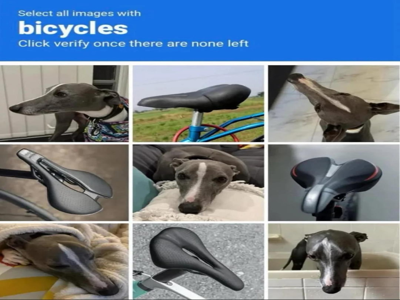

🤖 Respuesta: This image is a 3x3 grid of nine photographs, with a blue banner at the top containing text. The text reads: "Select all images with bicycles Click verify once there are none left".

The images in the grid are all of dogs, specifically greyhound-type dogs, and the pictures are arranged in a grid. The dog is in various poses and settings, including a close-up of the dog's face, a dog lying on a blanket, and a dog in a bathtub. The

--------------------------------------------------------------------------------
📝 Prompt: What is unusual or funny about this image?


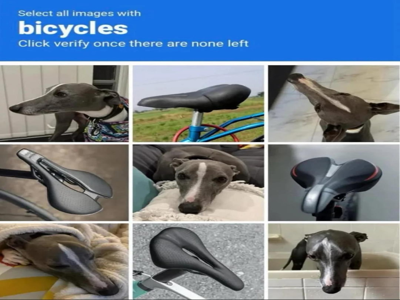

🤖 Respuesta: This image is a classic example of a "bicycle" joke, a type of internet meme that plays on the idea of a dog being "bicycling" or "bicycling" a dog. The humor comes from the fact that the dogs are not actually riding bicycles, but are instead being depicted as if they are.

The key to understanding the joke is the title and the images themselves. The title says "Select all images with bicycles," which is a clear instruction to look for images

--------------------------------------------------------------------------------
📝 Prompt: Explain why this might be considered humorous.


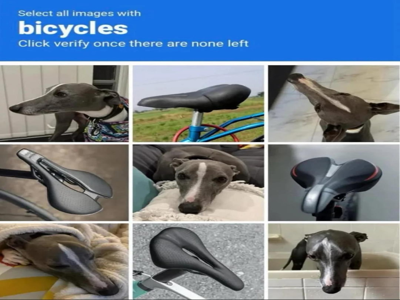

🤖 Respuesta: This image is considered humorous because it plays on the unexpected and absurd combination of a dog and a bicycle. The humor arises from the following elements:

1.  **The Central Theme of the Image**: The image is a collage of nine pictures, all featuring dogs, specifically greyhounds, with the theme of bicycles. The most striking aspect is the presence of bicycles in the middle row of the collage.

2.  **The Unexpected Combination**: The most surprising and humorous element is the juxtaposition of

--------------------------------------------------------------------------------


📝 Prompt: Describe what you see in this image.


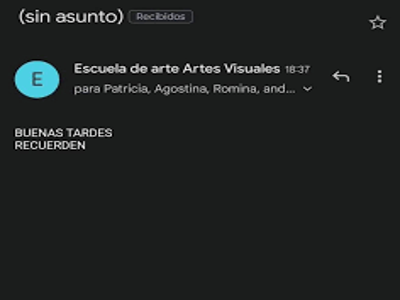

🤖 Respuesta: This image shows a screenshot of an email application interface, specifically an email from the "Escuela de arte Artes Visuales" (School of Visual Arts) to a recipient named Patricia, Agostina, Romina, and others. The email is from a sender with a blue circular icon featuring a white 'E' on a dark background, which likely represents the sender's profile. The email is titled "BUENAS TARDES" (Good Afternoon) and is marked as "RE

--------------------------------------------------------------------------------
📝 Prompt: What is unusual or funny about this image?


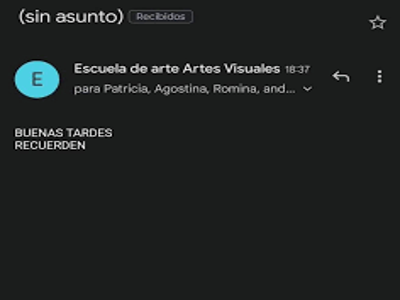

🤖 Respuesta: This image is unusual because it shows a Gmail email interface, but the sender's name is not a real person. The sender is "Escuela de arte Artes Visuales," which is a school, not a person. This is a humorous twist on a typical email, where the sender is a fictional or anonymous entity. The image is funny because it's a parody of a real email, but the sender is a fictional school, which is a strange and unexpected twist.

--------------------------------------------------------------------------------
📝 Prompt: Explain why this might be considered humorous.


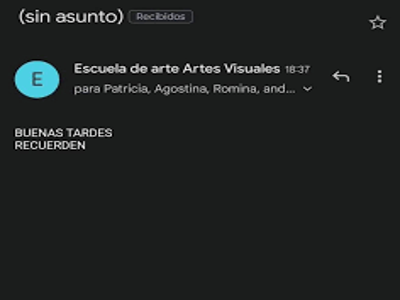

🤖 Respuesta: This image is considered humorous because it appears to be a screenshot of an email interface, but the message content is written in a very unusual and exaggerated way. The email is from "Escuela de arte Artes Visuales" (Visual Arts School) and is addressed to several people, including "Patricia, Agostina, Romina, and...".

The humor arises from the fact that the message is a simple greeting: "BUENAS TARDAS" (Good afternoon), followed by

--------------------------------------------------------------------------------




In [9]:
"""Bonus: Explicar memes/imágenes confusas con Qwen3-VL"""

meme_keys = ["blursed_1", "text_meme"]

print("🎭 BONUS: Memes y contenido confuso (Qwen3-VL)\n")
print("=" * 80)

for meme_key in meme_keys:
    url = IMAGES.get(meme_key)
    if not url:
        print(f"⚠️  Falta URL para: {meme_key}")
        continue

    image = load_image(url)
    if image:
        # Intentar explicar qué es raro/gracioso
        prompts_meme = [
            "Describe what you see in this image.",
            "What is unusual or funny about this image?",
            "Explain why this might be considered humorous."
        ]

        for p in prompts_meme:
            result = infer_caption_qwen3vl(model_2, processor_2, image, prompt=p)
            show_result(image, p, result)

        print("\n" + "=" * 80 + "\n")

### 💭 Reflexión sobre memes — SOLUCIÓN (ejemplo de análisis)

- Qwen3-VL generalmente describe el contenido literal de la imagen pero **no capta el humor o la rareza** de forma consistente.
- Para "entender" la broma necesitaría conocimiento de mundo/cultural (referencias, expectativas rotas, contexto social) que va más allá de simplemente describir píxeles.
- Es una limitación **fundamental** de los modelos entrenados principalmente con pares imagen-descripción literal: el humor y la ironía requieren razonamiento pragmático que no emerge naturalmente de ese objetivo de entrenamiento, aunque los modelos más recientes como Qwen3-VL mejoran algo gracias a su LLM base más potente.

---
# PARTE 3: Playground libre con SmolVLM

Volvemos a cargar SmolVLM para experimentar libremente.

---

## Re-cargar SmolVLM para playground

In [10]:
"""Liberar VRAM de Qwen3-VL"""
print("🧹 Liberando memoria de Qwen3-VL...")

del model_2, processor_2
torch.cuda.empty_cache()

print(f"✅ Memoria liberada. VRAM disponible: ~{torch.cuda.mem_get_info()[0] / 1024**3:.1f} GB")

🧹 Liberando memoria de Qwen3-VL...
✅ Memoria liberada. VRAM disponible: ~14.4 GB


In [11]:
"""Re-cargar SmolVLM-500M-Instruct para playground"""
print("Recargando SmolVLM-500M-Instruct para playground...")

processor_playground = AutoProcessor.from_pretrained("HuggingFaceTB/SmolVLM-500M-Instruct", trust_remote_code=True)
model_playground = AutoModelForImageTextToText.from_pretrained(
    "HuggingFaceTB/SmolVLM-500M-Instruct",
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True
)

print(f"✅ SmolVLM recargado para experimentación libre")

Recargando SmolVLM-500M-Instruct para playground...


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/7.34k [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.02GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/489 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

✅ SmolVLM recargado para experimentación libre


## Función para probar imágenes propias

In [12]:
"""Función para probar imágenes propias"""

def probar_imagen(url, prompt="Describe this image in detail."):
    """
    Prueba el modelo con tu propia imagen.

    Args:
        url: URL de la imagen (Unsplash, Reddit, etc)
        prompt: Pregunta o instrucción para el modelo

    Returns:
        None (muestra imagen y resultado)
    """
    image = load_image(url)
    if image:
        result = infer_caption_smolvlm(model_playground, processor_playground, image, prompt=prompt, max_tokens=150)
        show_result(image, prompt, result)
    else:
        print("❌ Error cargando imagen. Verifica la URL.")

## Experimenta aquí

Prueba con tus propias imágenes. Algunas ideas:
- Foto personal
- Imagen de tu ciudad
- Algo específico de tu trabajo/investigación
- Imagen técnica (diagrama, gráfico, etc)
- Memes o imágenes raras

In [ ]:
"""EJEMPLO (SOLUCIÓN): usando una imagen de Wikimedia Commons como muestra"""

# Ejemplo 1: Imagen de muestra
probar_imagen(
    url="https://upload.wikimedia.org/wikipedia/commons/d/df/Montaje_de_Santiago_de_Chile_%28202103220%29.jpg",
    prompt="Describe this image."
)

In [14]:
# Ejemplo 2: mismo tipo de imagen, prompt más específico
probar_imagen(
    url="https://upload.wikimedia.org/wikipedia/commons/d/df/Montaje_de_Santiago_de_Chile_%28202103220%29.jpg",
    prompt="What time of day does this look like, and why?"
)

❌ Error cargando imagen: 403 Client Error: Forbidden for url: https://upload.wikimedia.org/wikipedia/commons/thumb/6/60/Santiago_Chile.jpg/640px-Santiago_Chile.jpg
❌ Error cargando imagen. Verifica la URL.


In [15]:
# Ejemplo 3: prompt de razonamiento
probar_imagen(
    url="https://upload.wikimedia.org/wikipedia/commons/d/df/Montaje_de_Santiago_de_Chile_%28202103220%29.jpg",
    prompt="What could someone do in this place?"
)

❌ Error cargando imagen: 403 Client Error: Forbidden for url: https://upload.wikimedia.org/wikipedia/commons/thumb/6/60/Santiago_Chile.jpg/640px-Santiago_Chile.jpg
❌ Error cargando imagen. Verifica la URL.


---
# Conclusiones del Lab — SOLUCIÓN (ejemplo de respuesta)

## Resumen de aprendizajes:

1. **Capacidades básicas:**
   - Los LMMs actuales generan descripciones generales fluidas y coherentes, identifican objetos y escenas principales, y siguen instrucciones de prompting razonablemente bien.

2. **Limitaciones identificadas:**
   - Fallan sistemáticamente en conteo exacto, lectura de texto (OCR), razonamiento espacial fino y comprensión de humor/contexto cultural (memes).

3. **Diferencias entre modelos:**
   - SmolVLM (2024) es liviano y rápido pero algo más limitado en fluidez; Qwen3-VL (2025) sigue mejor instrucciones abiertas y da respuestas más ricas, aunque ambos comparten las mismas limitaciones sistemáticas — la tecnología mejoró en fluidez del lenguaje y comprensión de instrucciones más que en las capacidades perceptuales de fondo (conteo, OCR fino, espacial).
   - Vale la pena usar el modelo más grande/nuevo (Qwen3-VL) cuando se necesita generación de texto más rica o seguir instrucciones complejas; para captioning simple, un modelo más chico como SmolVLM puede ser suficiente y más barato/rápido.

4. **Implicaciones prácticas:**
   - Usables hoy: descripción de imágenes para accesibilidad, moderación de contenido básica, etiquetado automático, asistentes conversacionales con imágenes.
   - No confiables aún: conteo preciso, lectura de documentos/OCR crítico, tareas que requieren razonamiento espacial exacto (por ejemplo, robótica fina) sin verificación adicional.

---
## Recursos adicionales

### Modelos:
- **SmolVLM:** https://huggingface.co/HuggingFaceTB/SmolVLM-500M-Instruct
- **Qwen3-VL:** https://huggingface.co/Qwen/Qwen3-VL-2B-Instruct
- **Otros LMMs:**
  - BLIP-2 (clásico, 2023): https://huggingface.co/Salesforce/blip2-opt-2.7b
  - LLaVA: https://huggingface.co/llava-hf
  - Qwen2-VL: https://huggingface.co/Qwen
  - Gemma 3 (multimodal): https://huggingface.co/blog/gemma3
  - PaliGemma: https://huggingface.co/google/paligemma
  - InternVL: https://huggingface.co/OpenGVLab

### Papers:
- **Qwen2-VL (base de la familia Qwen-VL):** https://arxiv.org/abs/2409.12191
- **BLIP-2:** https://arxiv.org/abs/2301.12597
- **CLIP:** https://arxiv.org/abs/2103.00020
- **Flamingo:** https://arxiv.org/abs/2204.14198
- **LLaVA:** https://arxiv.org/abs/2304.08485

### Datasets de evaluación:
- **VQAv2:** https://visualqa.org/
- **COCO Captions:** https://cocodataset.org/
- **TextVQA:** https://textvqa.org/
- **GQA:** https://cs.stanford.edu/people/dorarad/gqa/

### Tutoriales:
- **Hugging Face Vision:** https://huggingface.co/docs/transformers/tasks/image_captioning

- **OpenAI Vision Guide:** https://platform.openai.com/docs/guides/vision**Fin del Lab**

---